# Notebook 6 - Predictive Modelling

Models built:
  1. ARIMA  - forecasts total yearly complaints and total yearly losses
  2. Random Forest Regressor - predicts per crime type complaints and losses

Inputs:
  data/processed/arima_yearly_totals.csv
  data/processed/rf_train.csv
  data/processed/rf_test.csv

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)

print("Libraries loaded")

Libraries loaded


## 2. Load Data

In [3]:
arima_df = pd.read_csv('data/processed/arima_yearly_totals.csv')
train    = pd.read_csv('data/processed/rf_train.csv')
test     = pd.read_csv('data/processed/rf_test.csv')

print("ARIMA data shape :", arima_df.shape)
print("RF train shape   :", train.shape)
print("RF test shape    :", test.shape)
print()
print(arima_df.to_string(index=False))

ARIMA data shape : (10, 4)
RF train shape   : (141, 14)
RF test shape    : (47, 14)

 Year  Total Complaints   Total Loss  Total Loss (Billions USD)
 2015          335003.0 1.221199e+09                     1.2212
 2016          354400.0 1.443696e+09                     1.4437
 2017          334326.0 1.720592e+09                     1.7206
 2018          423743.0 3.415816e+09                     3.4158
 2019          501119.0 4.384107e+09                     4.3841
 2020          780403.0 5.046417e+09                     5.0464
 2021          775222.0 7.647476e+09                     7.6475
 2022          685738.0 1.093060e+10                    10.9306
 2023          691701.0 1.234724e+10                    12.3472
 2024          651865.0 1.608841e+10                    16.0884


## 3. ARIMA - Total Complaints Forecast

In [4]:
complaints_series = arima_df.set_index('Year')['Total Complaints']

# Fit ARIMA(1,1,1) - d=1 for non-stationary series
arima_c = ARIMA(complaints_series, order=(1, 1, 1))
arima_c_fit = arima_c.fit()

print(arima_c_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Total Complaints   No. Observations:                   10
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -116.767
Date:                Sat, 11 Apr 2026   AIC                            239.535
Time:                        20:38:26   BIC                            240.126
Sample:                             0   HQIC                           238.258
                                 - 10                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6162      1.316     -0.468      0.640      -3.196       1.964
ma.L1          0.8995      0.927      0.970      0.332      -0.918       2.717
sigma2      1.673e+10   9.28e-11    1.8e+20      0.0

## Model Limitation

The ARIMA model is applied to a relatively small dataset (10 observations).
Model parameters are not statistically significant (p > 0.05), which further supports cautious interpretation of the model results.
Therefore, results should be interpreted as indicative of trend direction rather than precise forecasts.

In [5]:
# Forecast 3 years ahead (2025, 2026, 2027)
forecast_c = arima_c_fit.get_forecast(steps=3)
fc_c_mean  = forecast_c.predicted_mean
fc_c_ci    = forecast_c.conf_int()

fc_c_df = pd.DataFrame({
    'Year':       [2025, 2026, 2027],
    'Forecast':   fc_c_mean.values,
    'Lower 95%':  fc_c_ci.iloc[:, 0].values,
    'Upper 95%':  fc_c_ci.iloc[:, 1].values
})

print("Total Complaints Forecast:")
print(fc_c_df.to_string(index=False))
fc_c_df.to_csv('outputs/results/arima_complaints_forecast.csv', index=False)

Total Complaints Forecast:
 Year      Forecast     Lower 95%    Upper 95%
 2025 651645.658263 396899.281889 9.063920e+05
 2026 651780.822839 239222.830060 1.064339e+06
 2027 651697.530608 152216.714146 1.151178e+06


In [12]:
fitted_values = arima_c_fit.fittedvalues

# Align using index (safer)
common_index = complaints_series.index.intersection(fitted_values.index)

actual = complaints_series.loc[common_index]
fitted_values = fitted_values.loc[common_index]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, fitted_values)
rmse = np.sqrt(mean_squared_error(actual, fitted_values))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 93204.13300206713
RMSE: 139615.46749842894


### Model Evaluation Insight

The relatively high RMSE reflects the volatility and rapid growth in cybercrime trends, which are difficult to capture with limited time-series data.

This suggests that while the model captures general trends, prediction accuracy is constrained by the dynamic nature of cybercrime.

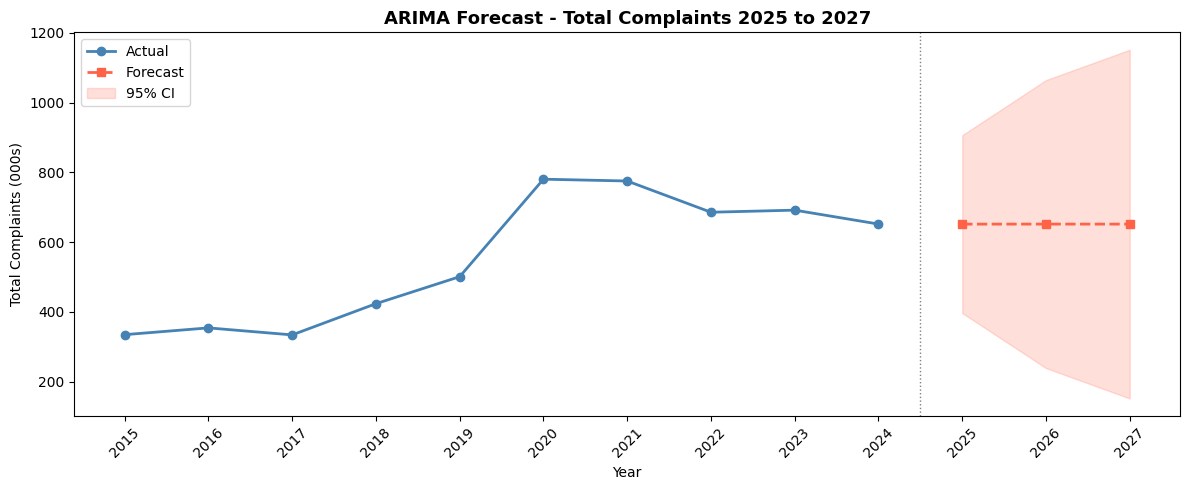

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(arima_df['Year'], arima_df['Total Complaints']/1e3,
        marker='o', label='Actual', color='steelblue', linewidth=2)
ax.plot([2025, 2026, 2027], fc_c_df['Forecast']/1e3,
        marker='s', linestyle='--', label='Forecast', color='tomato', linewidth=2)
ax.fill_between([2025, 2026, 2027],
                fc_c_df['Lower 95%']/1e3,
                fc_c_df['Upper 95%']/1e3,
                alpha=0.2, color='tomato', label='95% CI')

ax.axvline(x=2024.5, color='gray', linestyle=':', linewidth=1)
ax.set_title('ARIMA Forecast - Total Complaints 2025 to 2027', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Complaints (000s)')
ax.legend()
ax.set_xticks(list(arima_df['Year']) + [2025, 2026, 2027])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/nb5_arima_complaints_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ARIMA - Total Losses Forecast

In [7]:
loss_series = arima_df.set_index('Year')['Total Loss']

arima_l = ARIMA(loss_series, order=(1, 1, 1))
arima_l_fit = arima_l.fit()

forecast_l = arima_l_fit.get_forecast(steps=3)
fc_l_mean  = forecast_l.predicted_mean
fc_l_ci    = forecast_l.conf_int()

fc_l_df = pd.DataFrame({
    'Year':       [2025, 2026, 2027],
    'Forecast':   fc_l_mean.values,
    'Lower 95%':  fc_l_ci.iloc[:, 0].values,
    'Upper 95%':  fc_l_ci.iloc[:, 1].values
})

print("Total Loss Forecast ($):")
print(fc_l_df.to_string(index=False))
fc_l_df.to_csv('outputs/results/arima_loss_forecast.csv', index=False)

Total Loss Forecast ($):
 Year     Forecast    Lower 95%    Upper 95%
 2025 1.889224e+10 1.686732e+10 2.091717e+10
 2026 2.169605e+10 1.808707e+10 2.530503e+10
 2027 2.449982e+10 1.914951e+10 2.985014e+10


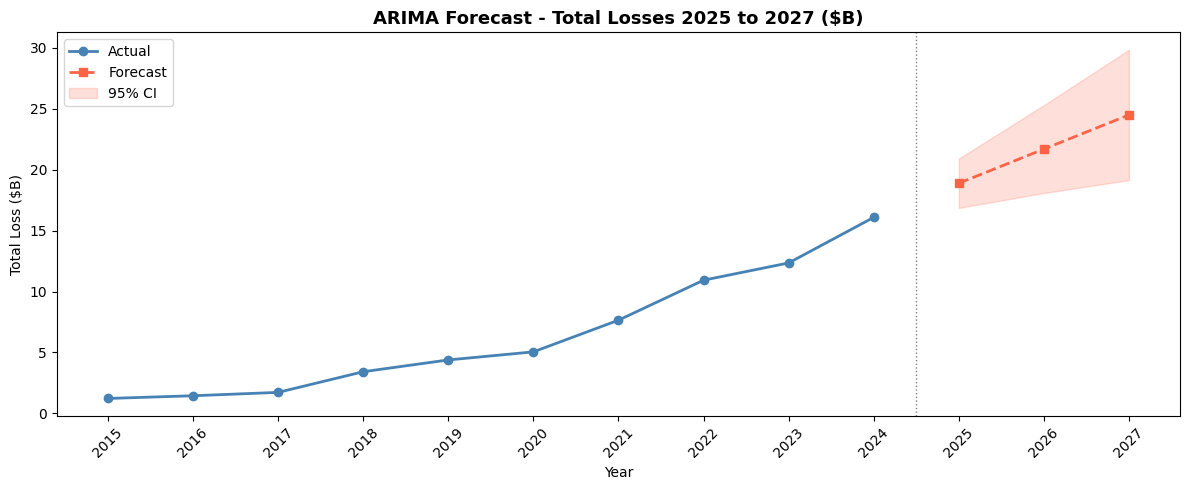

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(arima_df['Year'], arima_df['Total Loss']/1e9,
        marker='o', label='Actual', color='steelblue', linewidth=2)
ax.plot([2025, 2026, 2027], fc_l_df['Forecast']/1e9,
        marker='s', linestyle='--', label='Forecast', color='tomato', linewidth=2)
ax.fill_between([2025, 2026, 2027],
                fc_l_df['Lower 95%']/1e9,
                fc_l_df['Upper 95%']/1e9,
                alpha=0.2, color='tomato', label='95% CI')

ax.axvline(x=2024.5, color='gray', linestyle=':', linewidth=1)
ax.set_title('ARIMA Forecast - Total Losses 2025 to 2027 ($B)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Loss ($B)')
ax.legend()
ax.set_xticks(list(arima_df['Year']) + [2025, 2026, 2027])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/nb5_arima_loss_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Random Forest - Predict Complaints per Crime Type

In [9]:
FEATURE_COLS = [
    'Year', 'Crime_Code',
    'Complaints_Lag1', 'Complaints_Lag2', 'Complaints_Roll3',
    'Loss_Lag1', 'Loss_Lag2', 'Loss_Roll3',
    'Complaints_YoY', 'Loss_YoY', 'Loss_per_Complaint'
]

X_train = train[FEATURE_COLS]
y_train_c = train['Victim Count']

X_test  = test[FEATURE_COLS]
y_test_c  = test['Victim Count']

rf_c = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_c.fit(X_train, y_train_c)

pred_c = rf_c.predict(X_test)

mae_c  = mean_absolute_error(y_test_c, pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
r2_c   = r2_score(y_test_c, pred_c)

print("Random Forest - Complaints")
print(f"  MAE  : {mae_c:,.0f}")
print(f"  RMSE : {rmse_c:,.0f}")
print(f"  R2   : {r2_c:.4f}")

Random Forest - Complaints
  MAE  : 5,240
  RMSE : 15,715
  R2   : 0.9053


## 6. Random Forest - Predict Losses per Crime Type

In [12]:
y_train_l = train['Loss $']
y_test_l  = test['Loss $']

rf_l = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_l.fit(X_train, y_train_l)

pred_l = rf_l.predict(X_test)

mae_l  = mean_absolute_error(y_test_l, pred_l)
rmse_l = np.sqrt(mean_squared_error(y_test_l, pred_l))
r2_l   = r2_score(y_test_l, pred_l)

print("Random Forest - Losses")
print(f"  MAE  : ${mae_l:,.0f}")
print(f"  RMSE : ${rmse_l:,.0f}")
print(f"  R2   : {r2_l:.4f}")

Random Forest - Losses
  MAE  : $241,959,501
  RMSE : $682,309,513
  R2   : 0.6958


## 7. Model Performance Summary

In [13]:
summary = pd.DataFrame({
    'Model':  ['RF - Complaints', 'RF - Losses'],
    'MAE':    [round(mae_c, 0), round(mae_l, 0)],
    'RMSE':   [round(rmse_c, 0), round(rmse_l, 0)],
    'R2':     [round(r2_c, 4), round(r2_l, 4)]
})

print(summary.to_string(index=False))
summary.to_csv('outputs/results/rf_model_performance.csv', index=False)

          Model         MAE        RMSE     R2
RF - Complaints      5240.0     15715.0 0.9053
    RF - Losses 241959501.0 682309513.0 0.6958


## 8. Feature Importance

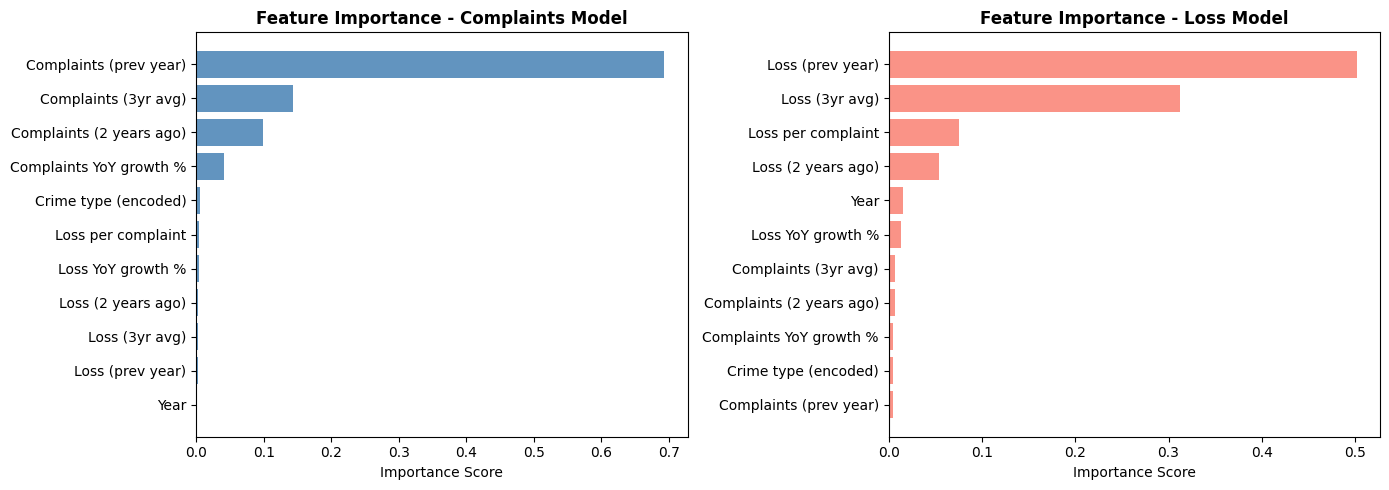

In [17]:
FEATURE_LABELS = {
    'Complaints_Lag1':    'Complaints (prev year)',
    'Complaints_Lag2':    'Complaints (2 years ago)',
    'Complaints_Roll3':   'Complaints (3yr avg)',
    'Loss_Lag1':          'Loss (prev year)',
    'Loss_Lag2':          'Loss (2 years ago)',
    'Loss_Roll3':         'Loss (3yr avg)',
    'Complaints_YoY':     'Complaints YoY growth %',
    'Loss_YoY':           'Loss YoY growth %',
    'Loss_per_Complaint': 'Loss per complaint',
    'Year':               'Year',
    'Crime_Code':         'Crime type (encoded)'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

imp_c = pd.Series(rf_c.feature_importances_, index=FEATURE_COLS).sort_values()
imp_l = pd.Series(rf_l.feature_importances_, index=FEATURE_COLS).sort_values()

imp_c.index = [FEATURE_LABELS[f] for f in imp_c.index]
imp_l.index = [FEATURE_LABELS[f] for f in imp_l.index]

ax1.barh(imp_c.index, imp_c.values, color='steelblue', alpha=0.85)
ax1.set_title('Feature Importance - Complaints Model', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance Score')

ax2.barh(imp_l.index, imp_l.values, color='salmon', alpha=0.85)
ax2.set_title('Feature Importance - Loss Model', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/figures/nb5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Actual vs Predicted (Test Set)

In [15]:
test_results = test[['Crime Type Harmonised', 'Year']].copy()
test_results['Actual Complaints']    = y_test_c.values
test_results['Predicted Complaints'] = pred_c.round(0)
test_results['Actual Loss']          = y_test_l.values
test_results['Predicted Loss']       = pred_l.round(0)

print(test_results.sort_values('Actual Complaints', ascending=False).head(15).to_string(index=False))
test_results.to_csv('outputs/results/rf_test_predictions.csv', index=False)

   Crime Type Harmonised  Year  Actual Complaints  Predicted Complaints  Actual Loss  Predicted Loss
                Phishing  2023           298878.0              300498.0   18728550.0     182242273.0
                Phishing  2024           193407.0              294434.0   70013036.0     156383228.0
               Extortion  2024            86415.0               76631.0  143185736.0     130563951.0
    Personal Data Breach  2024            64882.0               59246.0 1453296303.0    1202070031.0
    Personal Data Breach  2023            55851.0               56332.0  744219879.0     933574748.0
Non-Payment/Non-Delivery  2023            50523.0               57475.0  309648416.0     572984042.0
Non-Payment/Non-Delivery  2024            49572.0               55161.0  785436888.0     757219743.0
               Extortion  2023            48223.0               45656.0   74821835.0      91479815.0
              Investment  2024            47919.0               48489.0 6570639864.0    261

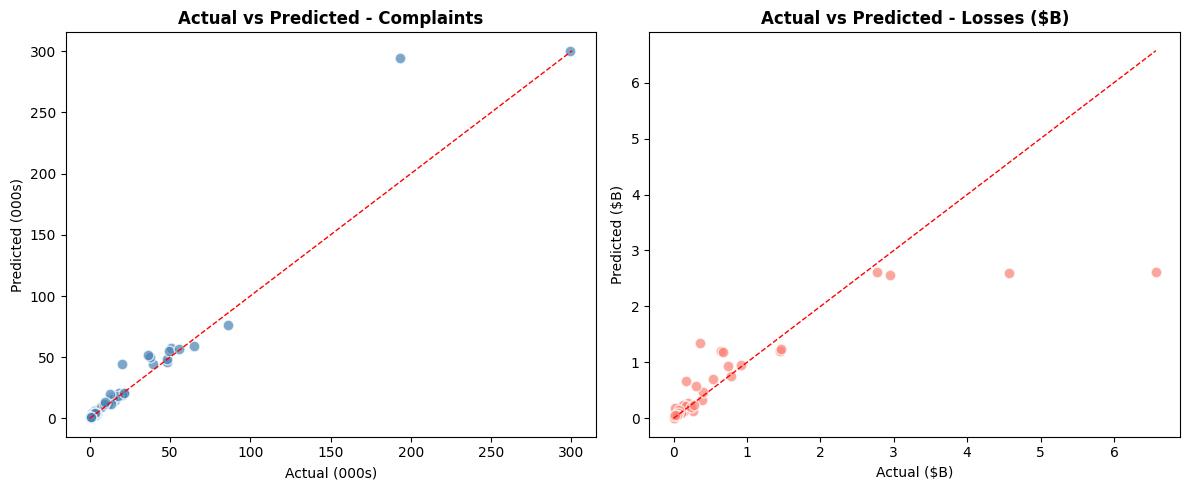

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_test_c/1e3, pred_c/1e3, alpha=0.7, color='steelblue', edgecolors='white', s=60)
max_c = max(y_test_c.max(), pred_c.max()) / 1e3
ax1.plot([0, max_c], [0, max_c], 'r--', linewidth=1)
ax1.set_title('Actual vs Predicted - Complaints', fontsize=12, fontweight='bold')
ax1.set_xlabel('Actual (000s)')
ax1.set_ylabel('Predicted (000s)')

ax2.scatter(y_test_l/1e9, pred_l/1e9, alpha=0.7, color='salmon', edgecolors='white', s=60)
max_l = max(y_test_l.max(), pred_l.max()) / 1e9
ax2.plot([0, max_l], [0, max_l], 'r--', linewidth=1)
ax2.set_title('Actual vs Predicted - Losses ($B)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Actual ($B)')
ax2.set_ylabel('Predicted ($B)')

plt.tight_layout()
plt.savefig('outputs/figures/nb5_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()